In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

1  Most frequent Value Imputation
2  Missing Category Imputation

In [3]:
df=pd.read_csv('train.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [4]:
df.isnull().mean()

FireplaceQu    0.472603
GarageQual     0.055479
SalePrice      0.000000
dtype: float64

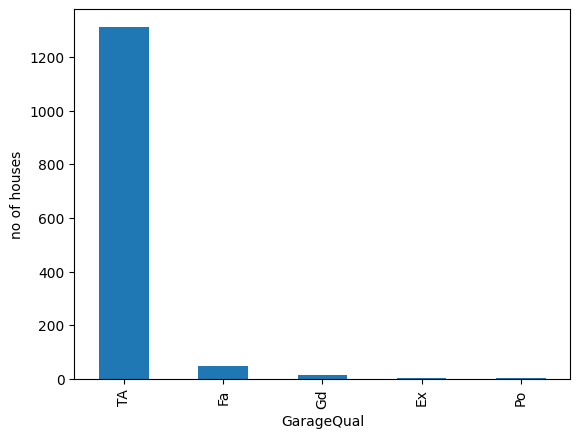

In [7]:
df['GarageQual'].value_counts().sort_values(ascending=False).plot.bar()
plt.xlabel('GarageQual')
plt.ylabel('no of houses')
plt.show()

In [8]:
df['GarageQual'].mode()

0    TA
Name: GarageQual, dtype: object

Text(0.5, 1.0, 'Garage Qual')

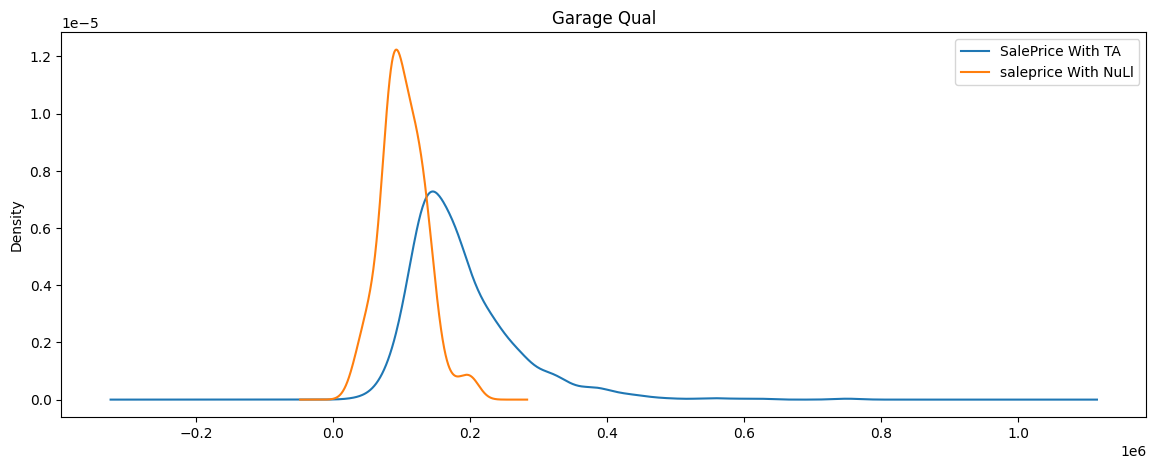

In [18]:
plt.figure(figsize=(14,5))
plt.subplot(111)
df[df['GarageQual']=='TA']['SalePrice'].plot(kind='kde',label='SalePrice With TA')

df[df['GarageQual'].isnull()]['SalePrice'].plot.kde(label='saleprice With NuLl')
plt.legend()
plt.title('Garage Qual')

In [19]:
temp=df[df['GarageQual']=='TA']['SalePrice']

In [20]:
df['GarageQual'].fillna('TA',inplace=True)

<Axes: title={'center': 'GarageQual'}, xlabel='GarageQual'>

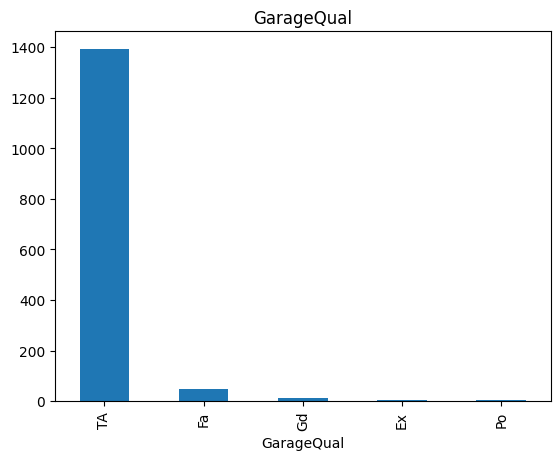

In [22]:
df['GarageQual'].value_counts().plot.bar(title='GarageQual')

<Axes: ylabel='Density'>

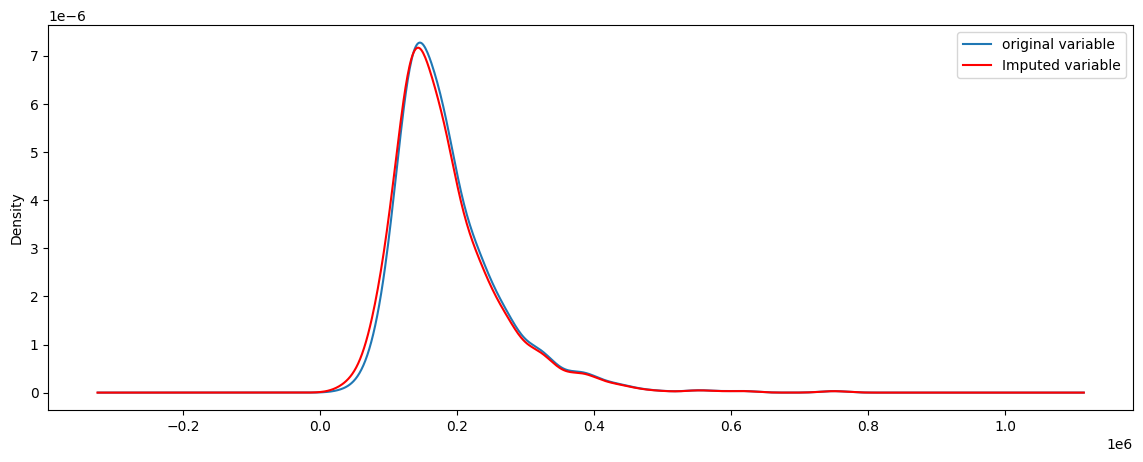

In [27]:
plt.figure(figsize=(14,5))
plt.subplot(111)

temp.plot(kind='kde',label='original variable',legend=True)

df[df['GarageQual']=='TA']['SalePrice'].plot.kde(color='red',label='Imputed variable',legend=True)

<Axes: xlabel='FireplaceQu'>

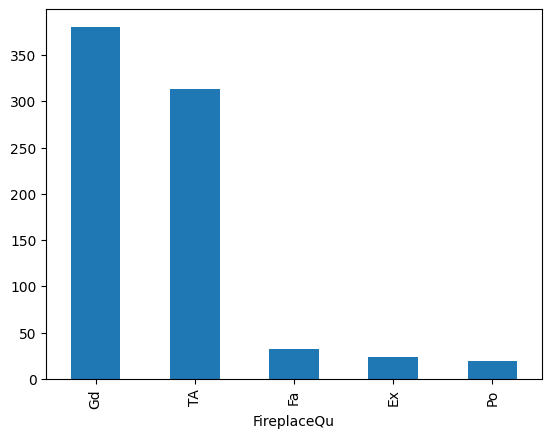

In [29]:
df['FireplaceQu'].value_counts().plot.bar()

In [30]:
df['FireplaceQu'].mode()

0    Gd
Name: FireplaceQu, dtype: object

Text(0.5, 1.0, 'FireQual')

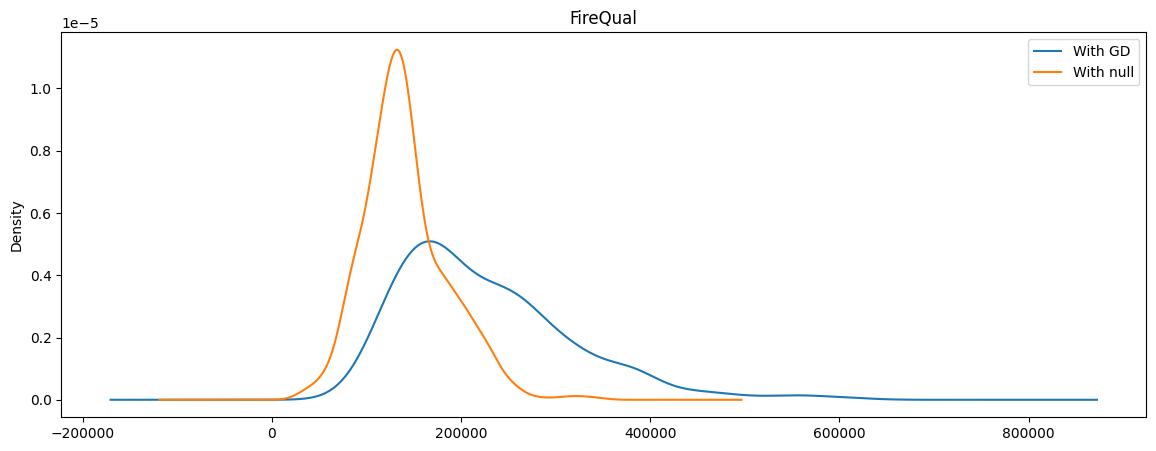

In [36]:
plt.figure(figsize=(14,5))
plt.subplot(111)
df[df['FireplaceQu']=='Gd']['SalePrice'].plot.kde(label='With GD',legend=True)
df[df['FireplaceQu'].isnull()]['SalePrice'].plot.kde(label='With null',legend=True)
plt.title('FireQual')

In [37]:
temp=df[df['FireplaceQu']=='Gd']['SalePrice']

In [38]:
df['FireplaceQu'].fillna('Gd',inplace=True)

<Axes: xlabel='FireplaceQu'>

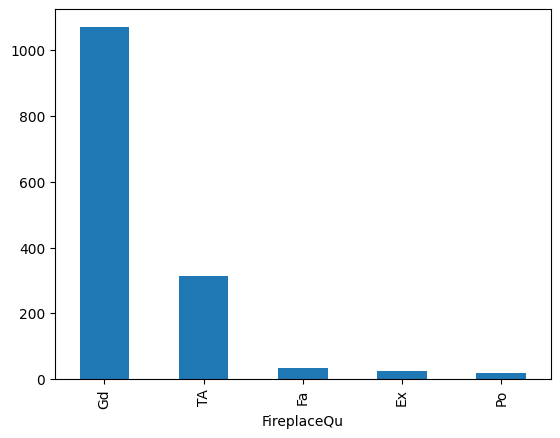

In [39]:
df['FireplaceQu'].value_counts().plot.bar()

<Axes: ylabel='Density'>

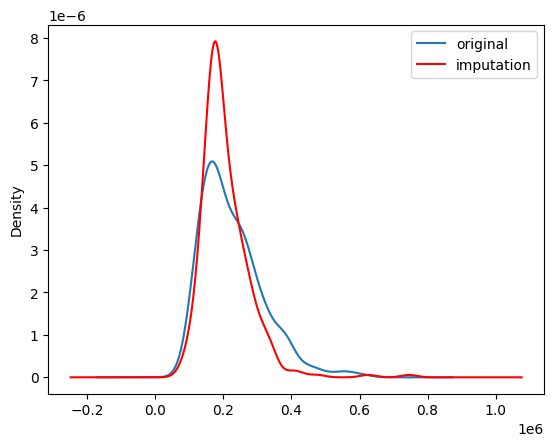

In [47]:
plt.Figure(figsize=(14,4))
plt.subplot(111)
temp.plot.kde(label='original',legend=True)
df[df['FireplaceQu']=='TA']['SalePrice'].plot.kde(color='red',label='imputation',legend=True)

Using Sklearn 

In [48]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.drop(columns=['SalePrice']),df['SalePrice'],test_size=0.2,random_state=42)

In [49]:
from sklearn.impute import SimpleImputer

In [50]:
imputer=SimpleImputer(strategy='most_frequent')

In [51]:
x_train=imputer.fit_transform(x_train)
x_test=imputer.transform(x_test)

In [52]:
imputer.statistics_

array(['Gd', 'TA'], dtype=object)

                     Missing Category Imputation

In [53]:
df=pd.read_csv('train.csv',usecols=['GarageQual','FireplaceQu','SalePrice'])

In [54]:
df.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [55]:
df.isnull().mean()

FireplaceQu    0.472603
GarageQual     0.055479
SalePrice      0.000000
dtype: float64

<Axes: xlabel='GarageQual'>

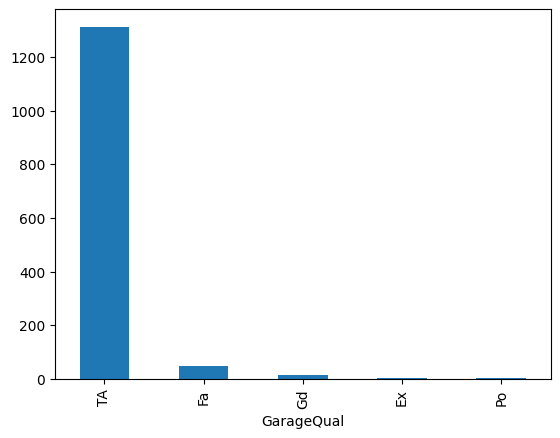

In [56]:
df['GarageQual'].value_counts().plot.bar()

<Axes: xlabel='GarageQual'>

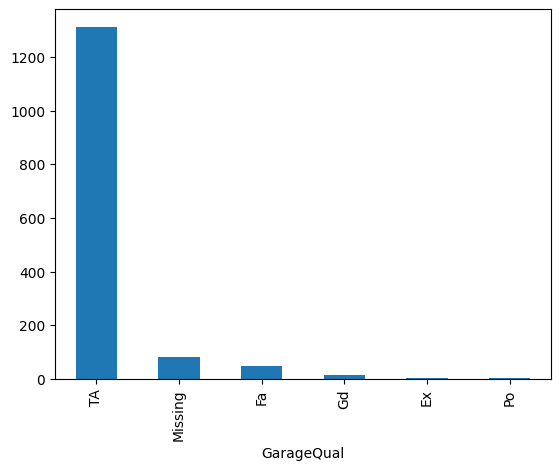

In [58]:
df['GarageQual'].fillna('Missing').value_counts().plot.bar()

Using Sklearn missing valur imputation

In [59]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.drop(columns=['SalePrice']),df['SalePrice'],test_size=0.2,random_state=42)

In [60]:
from sklearn.impute  import SimpleImputer

In [61]:
imputer=SimpleImputer(strategy='constant',fill_value='Missing')

In [63]:
x_train=imputer.fit_transform(x_train)
x_test=imputer.transform(x_test)

In [64]:
imputer.statistics_

array(['Missing', 'Missing'], dtype=object)